In [2]:
import pandas as pd

In [3]:
path = '/Users/philipp/Downloads/topology_feature_ssl — consolidated results - Sheet3.csv'
df = pd.read_csv(path)

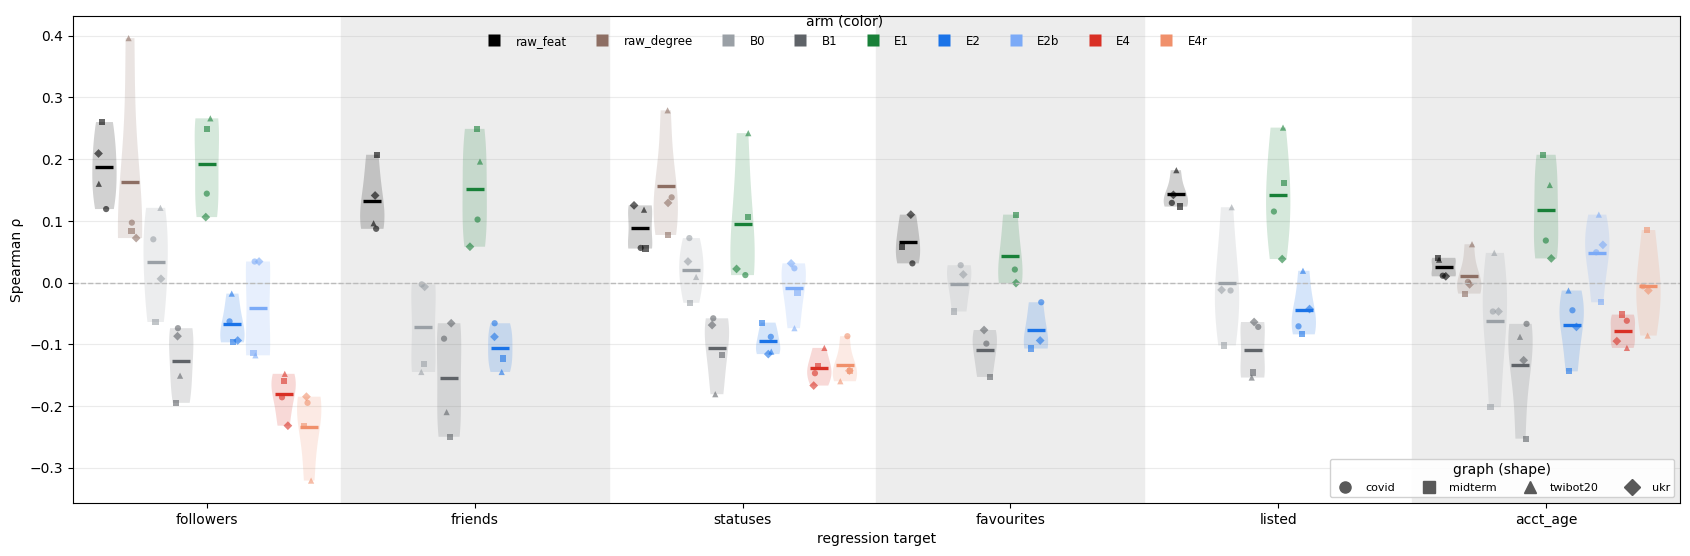

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

rng = np.random.default_rng(0)
d = df[df.task == "regression"]
arms  = ["raw_feat","raw_degree","B0","B1","E1","E2","E2b","E4","E4r"]   # floors first
tasks = ["followers","friends","statuses","favourites","listed","acct_age"]
COL = {"raw_feat":"#000000","raw_degree":"#8d6e63","B0":"#9aa0a6","B1":"#5f6368",
       "E1":"#188038","E2":"#1a73e8","E2b":"#7baaf7","E4":"#d93025","E4r":"#f0906b"}
MARK = {"covid":"o","midterm":"s","twibot20":"^","ukr":"D"}              # shape per graph

fig, ax = plt.subplots(figsize=(17, 5.6))

ax.set_axisbelow(True)                        # grid/bands stay under the data
for i in range(len(tasks)):
    if i % 2 == 1:                             # shade every other target
        ax.axvspan(i - 0.5, i + 0.5, color="0.93", zorder=-1)
ax.set_xlim(-0.5, len(tasks) - 0.5)           # bands align flush with the edges

w = 0.86 / len(arms)
for j, arm in enumerate(arms):
    off = (j - (len(arms)-1)/2) * w
    for i, t in enumerate(tasks):
        sub  = d[(d.arm==arm) & (d.item==t)]
        vals = sub["value"].dropna().values
        if len(vals) == 0: continue
        pos = i + off
        if len(vals) >= 2:                                       # faint violin
            vp = ax.violinplot([vals], positions=[pos], widths=w*0.95,
                               showextrema=False, showmeans=False, showmedians=False)
            for b in vp["bodies"]:
                b.set_facecolor(COL[arm]); b.set_alpha(0.18); b.set_edgecolor("none")
        for ds, mk in MARK.items():                              # points: shape per graph
            dv = sub[sub.dataset==ds]["value"].dropna().values
            if len(dv)==0: continue
            jit = rng.uniform(-w*0.24, w*0.24, size=len(dv))
            ax.scatter(pos+jit, dv, marker=mk, s=20, color=COL[arm],
                       alpha=0.6, edgecolor="none", zorder=2)
        ax.scatter([pos], [vals.mean()], marker="_", s=150,      # mean = wide tick
                   color=COL[arm], lw=2.4, zorder=4)

ax.axhline(0, color="#bbb", lw=1, ls="--")
ax.set_xticks(range(len(tasks))); ax.set_xticklabels(tasks)
ax.set_ylabel("Spearman ρ"); ax.set_xlabel("regression target")
ax.grid(axis="y", alpha=0.25)

from matplotlib.lines import Line2D

arm_handles   = [Line2D([], [], marker="s", ls="", ms=9, markerfacecolor=COL[a],
                        markeredgecolor="none", label=a) for a in arms]
graph_handles = [Line2D([], [], marker=m, ls="", ms=8, color="0.35", label=g)
                 for g, m in MARK.items()]

fig.subplots_adjust(top=0.86, bottom=0.12)          # reserve room  (instead of tight_layout)
fig.legend(handles=arm_handles, title="arm (color)", ncol=len(arms),
           loc="upper center", bbox_to_anchor=(0.5, 0.995), frameon=False, fontsize=8.5)
ax.legend(handles=graph_handles, title="graph (shape)", loc="lower right",
          ncol=4, fontsize=8, framealpha=0.9)

# do NOT call plt.tight_layout()  — that's what was clipping the color legend

plt.tight_layout()
plt.savefig("regression_violin.pdf", dpi=300, bbox_inches="tight")
# plt.show()

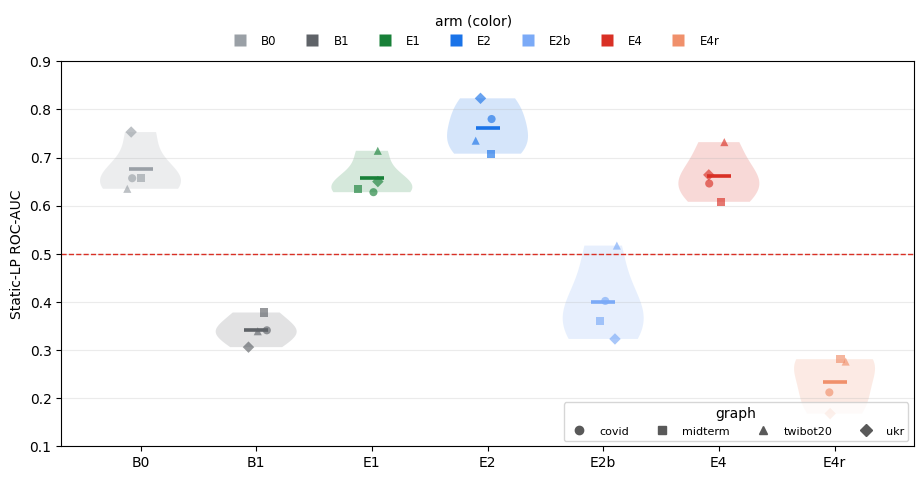

In [11]:
d = df[df.task == "static_lp"]
arms = ["B0","B1","E1","E2","E2b","E4","E4r"]
MARK = {"covid":"o","midterm":"s","twibot20":"^","ukr":"D"}
COL = {"B0":"#9aa0a6","B1":"#5f6368",
       "E1":"#188038","E2":"#1a73e8","E2b":"#7baaf7","E4":"#d93025","E4r":"#f0906b"}

fig, ax = plt.subplots(figsize=(11, 5))
for j, arm in enumerate(arms):
    sub = d[d.arm == arm]; vals = sub["value"].dropna().values
    if len(vals) >= 2:
        for b in ax.violinplot([vals], positions=[j], widths=0.7,
                               showextrema=False)["bodies"]:
            b.set_facecolor(COL[arm]); b.set_alpha(0.18); b.set_edgecolor("none")
    for ds, mk in MARK.items():
        dv = sub[sub.dataset == ds]["value"].dropna().values
        if len(dv):
            ax.scatter(j + rng.uniform(-0.12, 0.12, dv.size), dv, marker=mk, s=34,
                       color=COL[arm], alpha=0.65, edgecolor="none", zorder=2)
    ax.scatter([j], [vals.mean()], marker="_", s=300, color=COL[arm], lw=2.6, zorder=4)
ax.axhline(0.5, color="#d93025", ls="--", lw=1)
ax.set_xticks(range(len(arms))); ax.set_xticklabels(arms)
ax.set_ylabel("Static-LP ROC-AUC"); ax.set_ylim(0.1, 0.9); ax.grid(axis="y", alpha=0.25)
ax.legend(handles=[Line2D([],[],marker=m,ls="",color="0.35",label=g) for g,m in MARK.items()],
          title="graph", loc="lower right", ncol=4, fontsize=8)
arm_handles   = [Line2D([], [], marker="s", ls="", ms=9, markerfacecolor=COL[a],
                        markeredgecolor="none", label=a) for a in arms]
fig.legend(handles=arm_handles, title="arm (color)", ncol=len(arms),
           loc="upper center", bbox_to_anchor=(0.5, 0.995), frameon=False, fontsize=8.5)
# plt.tight_layout()

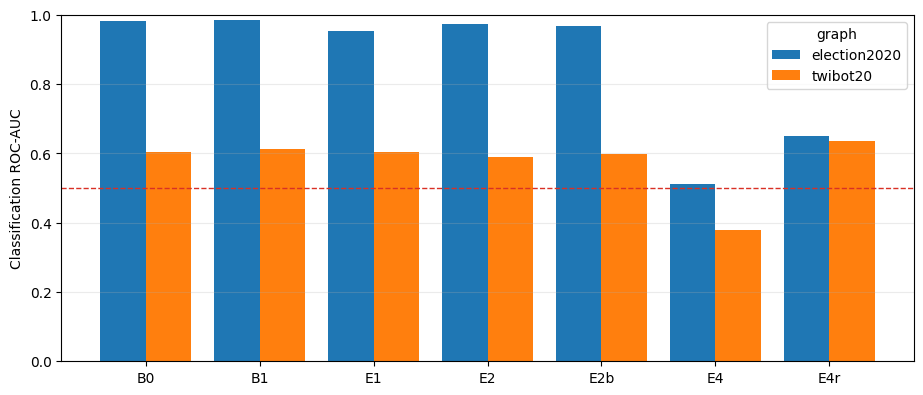

In [50]:
d = df[df.task == "classification"]; ds_order = ["election2020","twibot20"]
x = np.arange(len(arms)); w = 0.4
fig, ax = plt.subplots(figsize=(11, 4.5))
for k, ds in enumerate(ds_order):
    vals = [d[(d.arm==a)&(d.dataset==ds)]["value"].mean() for a in arms]
    ax.bar(x + (k-0.5)*w, vals, w, label=ds)
ax.axhline(0.5, color="#d93025", ls="--", lw=1)
ax.set_xticks(x); ax.set_xticklabels(arms); ax.set_ylabel("Classification ROC-AUC")
ax.set_ylim(0,1); ax.legend(title="graph"); ax.grid(axis="y", alpha=0.25)

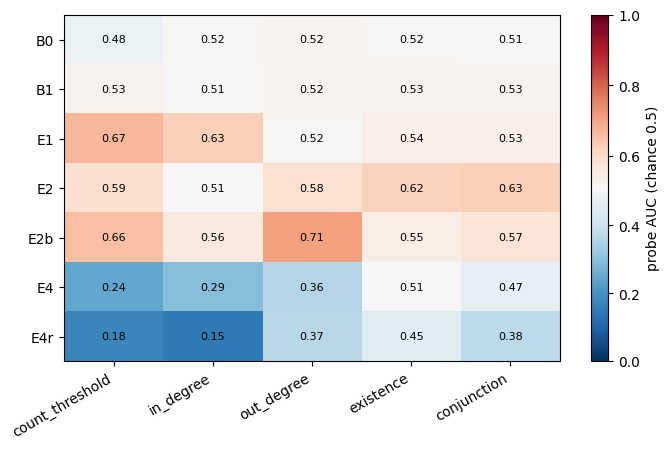

In [57]:
from matplotlib.colors import TwoSlopeNorm
rules = ["count_threshold","in_degree","out_degree","existence","conjunction"]
piv = df[df.task=="probe"].pivot_table(index="arm", columns="item", values="value").reindex(arms)[rules]
fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(piv.values, cmap="RdBu_r",
               norm=TwoSlopeNorm(vmin=0, vcenter=0.51, vmax=1), aspect="auto")
ax.set_xticks(range(len(rules))); ax.set_xticklabels(rules, rotation=30, ha="right")
ax.set_yticks(range(len(arms)));  ax.set_yticklabels(arms)
for i in range(piv.shape[0]):
    for k in range(piv.shape[1]):
        ax.text(k, i, f"{piv.values[i,k]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, label="probe AUC (chance 0.5)")

In [67]:
path = '/Users/philipp/Downloads/topology_feature_ssl — consolidated results - Raw_regression.csv'
raw = pd.read_csv(path)

In [75]:
df = raw.copy()
df = df[df.model.str.contains('40k')]
df['spearman_rank'] = df.groupby(['task', 'target', 'dataset'])['spearman'].rank(ascending=False, method='min')
df['rmse_rank'] = df.groupby(['task', 'target', 'dataset'])['rmse'].rank(ascending=False, method='min')
df['mae_rank'] = df.groupby(['task', 'target', 'dataset'])['mae'].rank(ascending=False, method='min')
df['r2_rank'] = df.groupby(['task', 'target', 'dataset'])['r2'].rank(ascending=False, method='min')
df['mse_rank'] = df.groupby(['task', 'target', 'dataset'])['mse'].rank(ascending=False, method='min')

In [96]:
# plot
df.groupby(['model', 'task', 'target', 'dataset']).spearman_rank.mean().groupby(['model', 'task', 'target']).mean().groupby(['model']).mean().sort_values()

model
E1_40k     1.319444
B0_40k     2.430556
E2b_40k    2.500000
E2_40k     3.680556
B1_40k     4.736111
E4r_40k    5.333333
E4_40k     5.833333
Name: spearman_rank, dtype: float64

## ladder

In [70]:
path = '/Users/philipp/projects/gfm/prodigy/scripts/experiments/analysis/transfer/ladders/prodigy_nm/canonical/nm_ladder/data/nmladder_results.csv'
df = pd.read_csv(path)

In [71]:
pdf = df.copy()
pdf.iloc[:,3:] =( df.iloc[:,3:] - df.iloc[0, 3:]).values

In [73]:
pdf = pdf.loc[[0,1,4,2,3]]

In [75]:
pdf

,rung,train_graph,sampling,ukr_rus_twitter,covid19_twitter,midterm,covid_political,election2020,ukr_rus_suspended,twibot20,cp_hk_twitter
0,1,ukr,within_balanced,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,2,ukr+cov,within_balanced,-0.003,0.007,0.011,-0.006,0.000,0.004,0.004,0.002
4,2,ukr+cov,within_proportional,-0.005,0.007,0.010,-0.003,0.006,0.011,0.007,0.000
2,3,ukr+cov+mid,within_balanced,-0.007,0.005,0.041,-0.019,-0.013,0.006,0.006,-0.004
3,4,all8,within_balanced,-0.014,0.002,0.034,0.057,0.092,0.160,0.016,0.143


In [76]:
pdf.set_index('train_graph')

,rung,sampling,ukr_rus_twitter,covid19_twitter,midterm,covid_political,election2020,ukr_rus_suspended,twibot20,cp_hk_twitter
train_graph,,,,,,,,,,
ukr,1,within_balanced,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
ukr+cov,2,within_balanced,-0.003,0.007,0.011,-0.006,0.000,0.004,0.004,0.002
ukr+cov,2,within_proportional,-0.005,0.007,0.010,-0.003,0.006,0.011,0.007,0.000
ukr+cov+mid,3,within_balanced,-0.007,0.005,0.041,-0.019,-0.013,0.006,0.006,-0.004
all8,4,within_balanced,-0.014,0.002,0.034,0.057,0.092,0.160,0.016,0.143


## similarity

In [109]:
path = "/Users/philipp/projects/gfm/prodigy/scripts/experiments/analysis/transfer/matrices/prodigy_nm/single_source/nm_single_source_matrix/data/transfer_pairs.csv"
df = pd.read_csv(path)

In [110]:
df['id'] = df['source'] + " → " + df['target']
df.set_index('id', inplace=True)

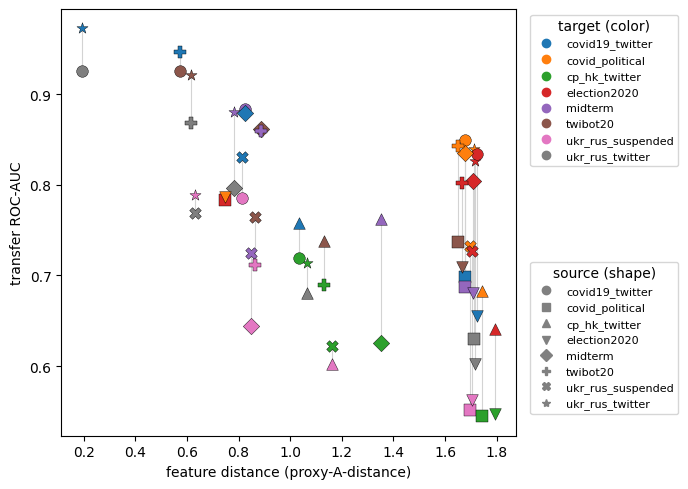

In [111]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

df = df[~df.is_self]                      # drop diagonal (distance 0, auc = ceiling)

x_col = "proxy_a_distance_sym"            # feature distance; swap for feat_mmd2 / feat_frechet / indegree_ks
targets = sorted(df.target.unique())
sources = sorted(df.source.unique())
colors  = dict(zip(targets, plt.get_cmap("tab10").colors))
markers = dict(zip(sources, ["o", "s", "^", "v", "D", "P", "X", "*"]))

fig, ax = plt.subplots(figsize=(7, 5))

# connect each pair to its reverse: (source,target) <-> (target,source)
lut = {(r.source, r.target): r for _, r in df.iterrows()}
seen = set()
for (s, t), r in lut.items():
    if (t, s) in lut and frozenset((s, t)) not in seen:
        seen.add(frozenset((s, t)))
        rr = lut[(t, s)]
        ax.plot([r[x_col], rr[x_col]], [r.transfer_auc, rr.transfer_auc],
                color="lightgray", lw=0.8, zorder=0)

for _, r in df.iterrows():
    ax.scatter(r[x_col], r.transfer_auc,
               color=colors[r.target], marker=markers[r.source],
               s=70, edgecolor="k", linewidth=0.3, zorder=2)

ax.set_xlabel("feature distance (proxy-A-distance)")
ax.set_ylabel("transfer ROC-AUC")

leg_c = ax.legend(handles=[Line2D([0], [0], marker="o", ls="", color=colors[t], label=t) for t in targets],
                  title="target (color)", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.add_artist(leg_c)
ax.legend(handles=[Line2D([0], [0], marker=markers[s], ls="", color="gray", label=s) for s in sources],
          title="source (shape)", bbox_to_anchor=(1.02, 0.42), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

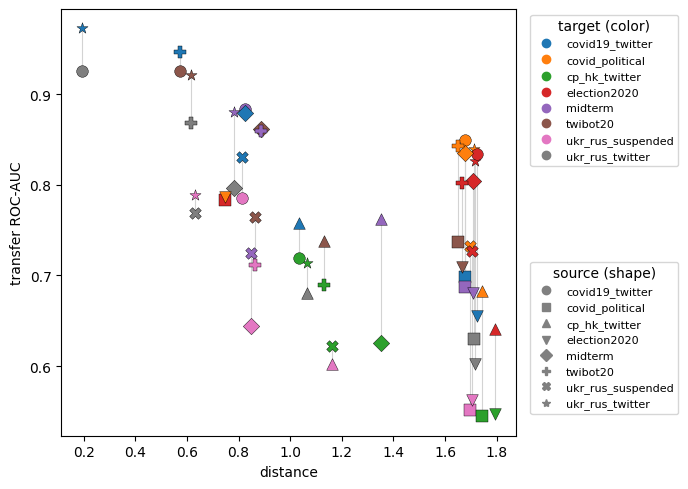

In [107]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

df = df[~df.is_self]                      # drop diagonal (distance 0, auc = ceiling)

x_col = "proxy_a_distance_sym"            # feature distance; swap for feat_mmd2 / feat_frechet / indegree_ks / proxy_a_distance_sym
targets = sorted(df.target.unique())
sources = sorted(df.source.unique())
colors  = dict(zip(targets, plt.get_cmap("tab10").colors))
markers = dict(zip(sources, ["o", "s", "^", "v", "D", "P", "X", "*"]))

fig, ax = plt.subplots(figsize=(7, 5))

# connect each pair to its reverse: (source,target) <-> (target,source)
lut = {(r.source, r.target): r for _, r in df.iterrows()}
seen = set()
for (s, t), r in lut.items():
    if (t, s) in lut and frozenset((s, t)) not in seen:
        seen.add(frozenset((s, t)))
        rr = lut[(t, s)]
        ax.plot([r[x_col], rr[x_col]], [r.transfer_auc, rr.transfer_auc],
                color="lightgray", lw=0.8, zorder=0)

for _, r in df.iterrows():
    ax.scatter(r[x_col], r.transfer_auc,
               color=colors[r.target], marker=markers[r.source],
               s=70, edgecolor="k", linewidth=0.3, zorder=2)

ax.set_xlabel("distance")
ax.set_ylabel("transfer ROC-AUC")

leg_c = ax.legend(handles=[Line2D([0], [0], marker="o", ls="", color=colors[t], label=t) for t in targets],
                  title="target (color)", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.add_artist(leg_c)
ax.legend(handles=[Line2D([0], [0], marker=markers[s], ls="", color="gray", label=s) for s in sources],
          title="source (shape)", bbox_to_anchor=(1.02, 0.42), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

In [162]:
order = ["covid19_twitter","ukr_rus_twitter","twibot20","midterm",
         "ukr_rus_suspended","cp_hk_twitter","covid_political","election2020"]
reg_mat = df.pivot(index="source", columns="target", values="regret").loc[order, order].fillna(0)

In [ ]:
order = ["covid19_twitter","ukr_rus_twitter","twibot20","midterm",
         "ukr_rus_suspended","cp_hk_twitter","covid_political","election2020"]
proxa_mat = df.pivot(index="source", columns="target", values="proxy_a_distance").loc[order, order].fillna(0)

<Axes: xlabel='proxy_a_distance_sym', ylabel='regret'>

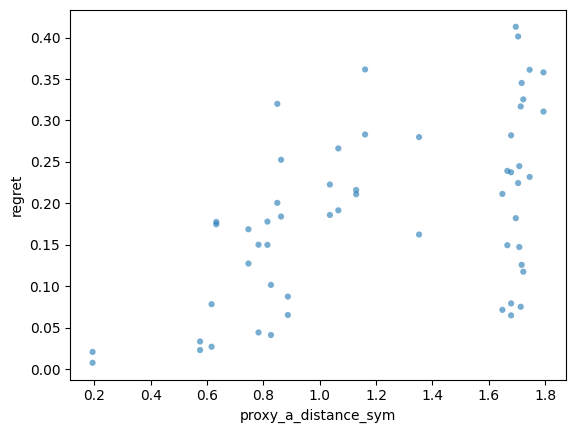

In [158]:
df.plot.scatter(x='proxy_a_distance_sym', y='regret', alpha=0.6, s=20, edgecolor="none",)

In [157]:
import pandas as pd, numpy as np
from itertools import permutations

SYMMETRIZE = False
TOL = 1e-9

nodes = sorted(set(df.source) | set(df.target))
D = (df.pivot(index="source", columns="target", values="regret")
       .reindex(index=nodes, columns=nodes))

M = np.array(D.to_numpy(), dtype=float)   # writable copy (this is the fix)
np.fill_diagonal(M, 0.0)                   # self-distance = 0
if SYMMETRIZE:
    M = (M + M.T) / 2
assert not np.isnan(M).any(), "missing pairs — matrix has NaNs"

rows = []
for i, j, k in permutations(range(len(nodes)), 3):   # distinct i,j,k; j is the intermediate
    slack = M[i, j] + M[j, k] - M[i, k]              # >=0 OK; <0 is a violation
    rows.append((nodes[i], nodes[j], nodes[k], M[i, k], M[i, j] + M[j, k], slack))

tri = pd.DataFrame(rows, columns=["i", "j", "k", "d_ik", "d_ij+d_jk", "slack"])
viol = tri[tri.slack < -TOL]

print(f"{len(viol)} / {len(tri)} triples violate d(i,k) <= d(i,j)+d(j,k)")
if len(viol):
    print(viol.sort_values("slack").head(10).to_string(index=False))
else:
    r = tri.loc[tri.slack.idxmin()]
    print(f"holds — tightest triangle slack {r.slack:.4f} ({r.i}->{r.k} via {r.j})")

16 / 336 triples violate d(i,k) <= d(i,j)+d(j,k)
              i               j                 k   d_ik  d_ij+d_jk   slack
   election2020        twibot20   covid19_twitter 0.3254     0.2723 -0.0531
       twibot20 covid19_twitter ukr_rus_suspended 0.2525     0.2111 -0.0414
        midterm covid19_twitter ukr_rus_suspended 0.3200     0.2794 -0.0406
covid_political        twibot20   covid19_twitter 0.2820     0.2445 -0.0375
   election2020        twibot20   ukr_rus_twitter 0.3452     0.3173 -0.0279
        midterm covid19_twitter   ukr_rus_twitter 0.1500     0.1221 -0.0279
covid_political        twibot20   ukr_rus_twitter 0.3169     0.2895 -0.0274
       twibot20 covid19_twitter   ukr_rus_twitter 0.0782     0.0538 -0.0244
  cp_hk_twitter covid19_twitter   ukr_rus_twitter 0.2662     0.2432 -0.0230
covid_political covid19_twitter   ukr_rus_twitter 0.3169     0.3026 -0.0143


<Axes: xlabel='target', ylabel='source'>

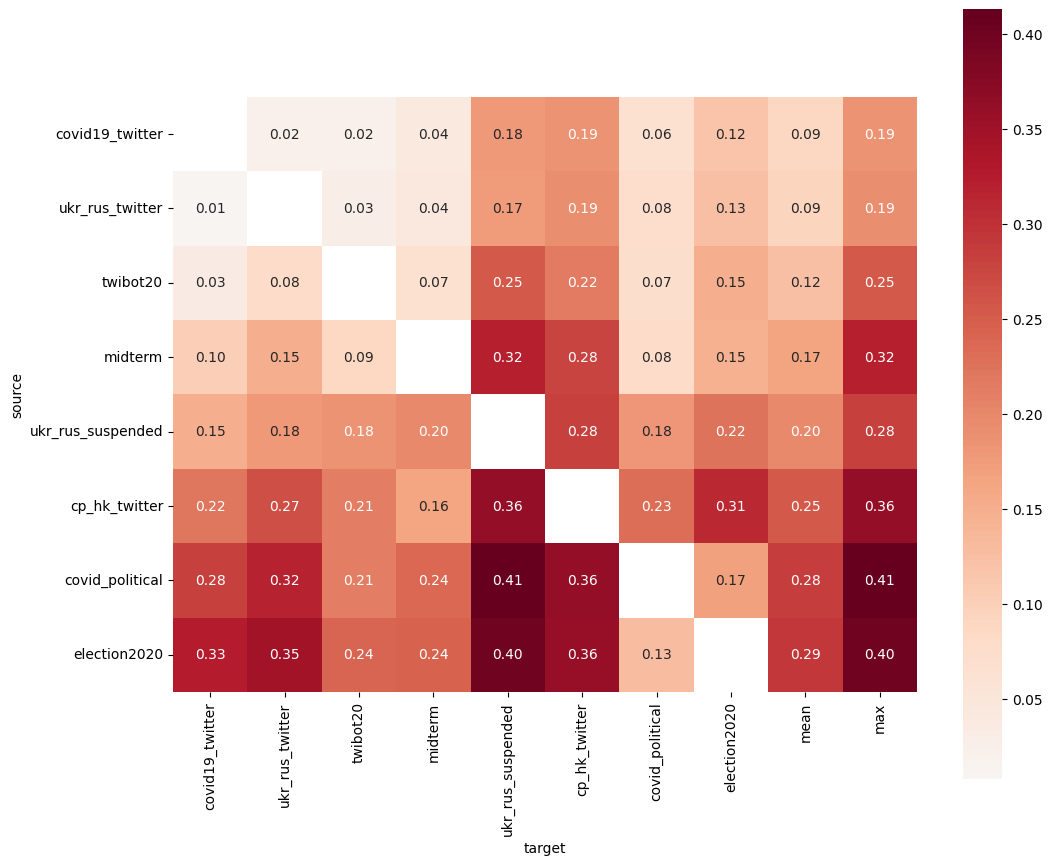

In [256]:
import seaborn as sns
plt.figure(figsize=(12,10))

reg_mat_p = reg_mat.copy()
reg_mat_p['mean'] = reg_mat_p.mean(axis=1)
reg_mat_p['max'] = reg_mat_p.max(axis=1)
sns.heatmap(reg_mat_p, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)